<a href="https://colab.research.google.com/github/3011stan/ann-exercises-ifes/blob/main/03_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting com Airline Passengers

Esta atividade aplica uma tecnica de forecasting vista em aula a uma base diferente da base Jena Climate. A serie usada e Airline Passengers, com observacoes mensais de passageiros internacionais. O notebook compara uma baseline Naive com um modelo Dense simples.

## Bibliotecas

Usaremos Pandas e NumPy para carregar e preparar a serie, Matplotlib para visualizacao, Scikit-Learn para metricas e TensorFlow/Keras para o modelo Dense.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
WINDOW_SIZE = 12
SAMPLING_RATE = 1
DELAY = 1
SHUFFLE = False
EPOCHS = 100
BATCH_SIZE = 16

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
MODEL_PATH = Path('models/airline_dense.keras')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## Base de dados

A base Airline Passengers contem a quantidade mensal de passageiros internacionais de companhias aereas entre 1949 e 1960. Ela tem 144 observacoes mensais e uma unica variavel numerica, `Passengers`.

Esta base foi escolhida porque e diferente da base Jena Climate usada na aula e diferente de Bike Sharing. Como a serie e mensal, ela tambem permite justificar uma janela de 12 meses por causa da sazonalidade anual.

In [2]:
df = pd.read_csv(DATA_URL)
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month').reset_index(drop=True)

series = df['Passengers'].astype('float32').to_numpy()
dates = df['Month'].to_numpy()

print(df.head())
print('\nLinhas:', len(df))
print('Inicio:', df['Month'].min().date())
print('Fim:', df['Month'].max().date())
print('Valores minimo e maximo:', series.min(), series.max())

       Month  Passengers
0 1949-01-01         112
1 1949-02-01         118
2 1949-03-01         132
3 1949-04-01         129
4 1949-05-01         121

Linhas: 144
Inicio: 1949-01-01
Fim: 1960-12-01
Valores minimo e maximo: 104.0 622.0


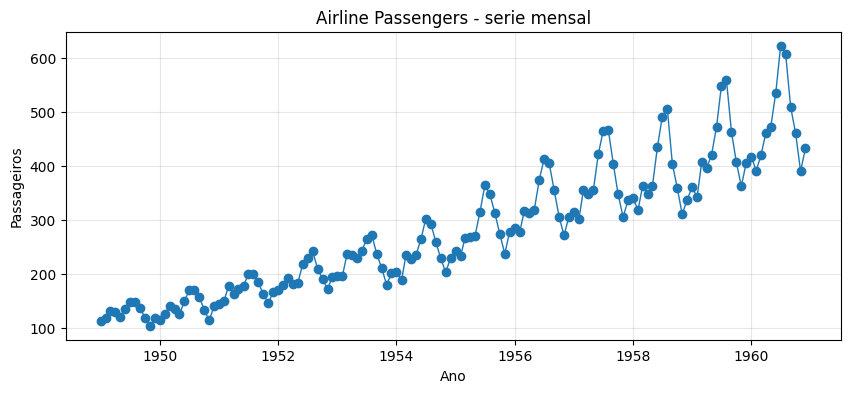

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(df['Month'], df['Passengers'], marker='o', linewidth=1)
plt.title('Airline Passengers - serie mensal')
plt.xlabel('Ano')
plt.ylabel('Passageiros')
plt.grid(True, alpha=0.3)
plt.show()

## Split temporal

Seguindo a divisao usada no notebook da aula, a serie foi separada em 50% treino, 25% validacao e 25% teste. A ordem temporal foi preservada, sem embaralhamento.

In [4]:
n = len(series)
num_train_samples = int(0.5 * n)
num_val_samples = int(0.25 * n)
num_test_samples = n - num_train_samples - num_val_samples

train_end = num_train_samples
val_end = num_train_samples + num_val_samples

print('Total:', n)
print('Treino:', num_train_samples)
print('Validacao:', num_val_samples)
print('Teste:', num_test_samples)
print('Indices treino: 0 a', train_end - 1)
print('Indices validacao:', train_end, 'a', val_end - 1)
print('Indices teste:', val_end, 'a', n - 1)

Total: 144
Treino: 72
Validacao: 36
Teste: 36
Indices treino: 0 a 71
Indices validacao: 72 a 107
Indices teste: 108 a 143


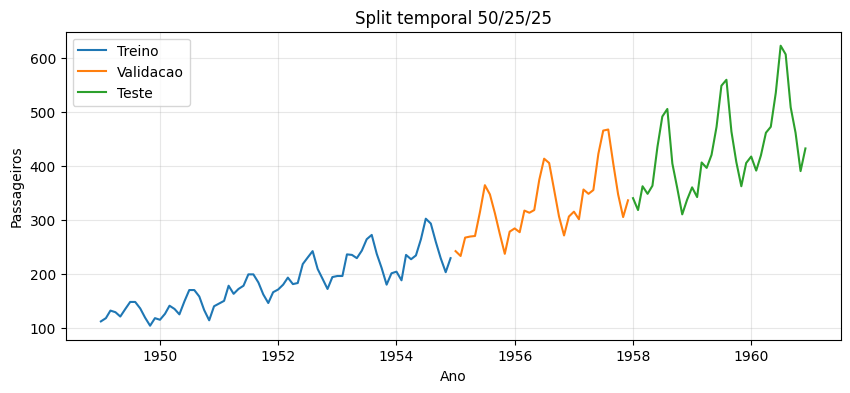

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(df['Month'][:train_end], series[:train_end], label='Treino')
plt.plot(df['Month'][train_end:val_end], series[train_end:val_end], label='Validacao')
plt.plot(df['Month'][val_end:], series[val_end:], label='Teste')
plt.title('Split temporal 50/25/25')
plt.xlabel('Ano')
plt.ylabel('Passageiros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Normalizacao

Assim como na aula, a normalizacao usa apenas estatisticas do trecho de treino. Depois das previsoes, desfazemos a normalizacao para calcular MAE e RMSE na escala original de passageiros.

In [6]:
train_mean = series[:train_end].mean()
train_std = series[:train_end].std()
series_norm = (series - train_mean) / train_std

def denormalize(values):
    return values * train_std + train_mean


print(f'Media do treino: {train_mean:.2f}')
print(f'Desvio padrao do treino: {train_std:.2f}')

Media do treino: 182.90
Desvio padrao do treino: 47.37


## Geracao de janelas

O dataset supervisionado e gerado a partir da serie normalizada. Cada entrada usa os 12 meses anteriores e o alvo e o mes seguinte.

- `WINDOW_SIZE = 12`: usa um ciclo anual completo.
- `SAMPLING_RATE = 1`: usa todos os meses, sem pular observacoes.
- `DELAY = 1`: previsao do proximo mes.
- `SHUFFLE = False`: preserva a ordem temporal.

As janelas sao divididas pelo indice temporal do alvo. Uma janela pode usar meses anteriores ao inicio do bloco, porque em forecasting real o passado ja e conhecido.

In [7]:
def make_windowed_dataset(values, dates, window_size, delay=1):
    X, y, target_dates, target_indices = [], [], [], []
    first_target = window_size + delay - 1
    for target_idx in range(first_target, len(values)):
        start = target_idx - delay - window_size + 1
        end = start + window_size
        X.append(values[start:end])
        y.append(values[target_idx])
        target_dates.append(dates[target_idx])
        target_indices.append(target_idx)
    return (
        np.array(X, dtype='float32'),
        np.array(y, dtype='float32'),
        np.array(target_dates),
        np.array(target_indices),
    )


X_all, y_all, window_dates, target_indices = make_windowed_dataset(
    series_norm, dates, WINDOW_SIZE, delay=DELAY
)

train_mask = target_indices < train_end
val_mask = (target_indices >= train_end) & (target_indices < val_end)
test_mask = target_indices >= val_end

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]
dates_test = window_dates[test_mask]

print('X_all:', X_all.shape)
print('y_all:', y_all.shape)
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:', X_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)
print('Primeiro indice alvo de treino:', target_indices[train_mask][0])
print('Primeiro indice alvo de validacao:', target_indices[val_mask][0])
print('Primeiro indice alvo de teste:', target_indices[test_mask][0])

X_all: (132, 12)
y_all: (132,)
X_train: (60, 12) y_train: (60,)
X_val: (36, 12) y_val: (36,)
X_test: (36, 12) y_test: (36,)
Primeiro indice alvo de treino: 12
Primeiro indice alvo de validacao: 72
Primeiro indice alvo de teste: 108


## Baseline Naive

A tecnica ingenua usa o ultimo valor observado na janela como previsao para o proximo mes. Essa baseline e importante porque modelos neurais simples podem nao superar uma regra direta em series pequenas.

In [8]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


y_test_original = denormalize(y_test)
naive_pred_norm = X_test[:, -1]
naive_pred = denormalize(naive_pred_norm)

naive_mae, naive_rmse = regression_metrics(y_test_original, naive_pred)
print(f'Naive MAE: {naive_mae:.2f} passageiros')
print(f'Naive RMSE: {naive_rmse:.2f} passageiros')

Naive MAE: 42.33 passageiros
Naive RMSE: 50.30 passageiros


## Modelo Dense

O modelo nao ingenuo segue a primeira abordagem neural da aula: uma rede Dense simples aplicada sobre a janela temporal. Como a serie tem apenas 144 observacoes, a arquitetura foi mantida pequena para reduzir overfitting.

In [9]:
inputs = keras.Input(shape=(WINDOW_SIZE,))
x = layers.Dense(16, activation='relu')(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor='val_mae',
        save_best_only=True,
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE,
    callbacks=callbacks,
    verbose=0,
)

best_model = keras.models.load_model(MODEL_PATH)
val_loss, val_mae = best_model.evaluate(X_val, y_val, verbose=0)
print(f'Melhor MAE de validacao normalizado: {val_mae:.4f}')

Melhor MAE de validacao normalizado: 0.3547


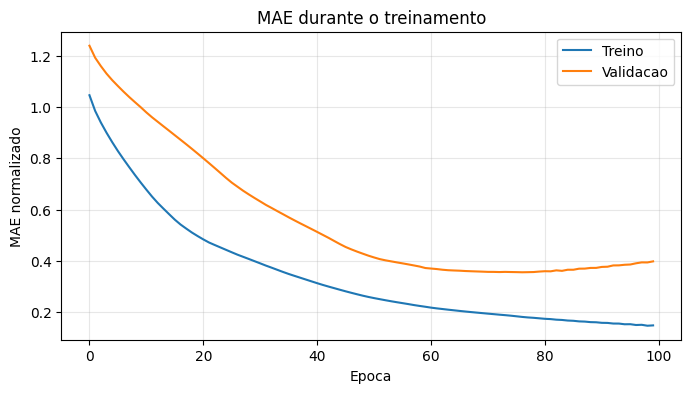

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['mae'], label='Treino')
plt.plot(history.history['val_mae'], label='Validacao')
plt.title('MAE durante o treinamento')
plt.xlabel('Epoca')
plt.ylabel('MAE normalizado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Avaliacao

As previsoes do modelo Dense sao convertidas de volta para a escala original de passageiros. A comparacao usa MAE e RMSE para a baseline Naive e para o modelo Dense.

In [12]:
dense_pred_norm = best_model.predict(X_test, verbose=0).reshape(-1)
dense_pred = denormalize(dense_pred_norm)

dense_mae, dense_rmse = regression_metrics(y_test_original, dense_pred)

results = pd.DataFrame({
    'Modelo': ['Naive', 'Dense'],
    'MAE': [naive_mae, dense_mae],
    'RMSE': [naive_rmse, dense_rmse],
})
results

,Modelo,MAE,RMSE
0,Naive,42.333332,50.299659
1,Dense,20.839453,26.107557


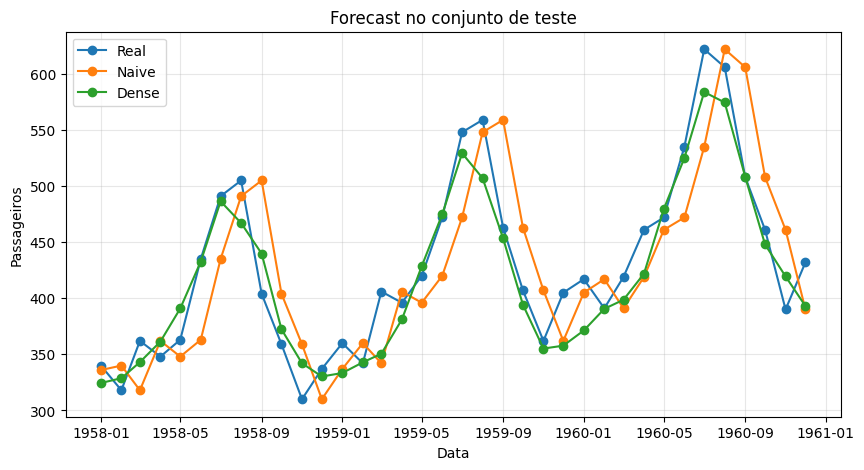

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(dates_test, y_test_original, marker='o', label='Real')
plt.plot(dates_test, naive_pred, marker='o', label='Naive')
plt.plot(dates_test, dense_pred, marker='o', label='Dense')
plt.title('Forecast no conjunto de teste')
plt.xlabel('Data')
plt.ylabel('Passageiros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusao

A atividade usou a base Airline Passengers, diferente da base Jena Climate da aula e diferente de Bike Sharing. A serie foi dividida temporalmente em 50% treino, 25% validacao e 25% teste. A normalizacao usou apenas a media e o desvio padrao do treino, seguindo a logica apresentada em aula.

A janela de 12 meses foi escolhida porque a serie e mensal e apresenta sazonalidade anual. A baseline Naive usa o ultimo valor da janela para prever o mes seguinte. O modelo Dense representa uma tecnica neural simples de forecasting, tambem inspirada na aula.
